# Woody Metrics — Workflow & Kurzbeschreibung

Version: 0.1 (2025-11-03) © R Butzer

Dieses Notebook erstellt und analysiert Woody‑Cover‑Metriken auf einem einheitlichen Raster‑Grid (z.B. 500 m / 3 km). Es enthält Schritte zur Reprojektion, Aggregation, Maskierung, Berechnung zeitlicher Metriken, Clustering und Visualisierung für gebrannte Flächen.

### Kurz: Was das Notebook macht
- Reprojektieren und resampeln (GDAL) der Woody‑Cover‑Daten auf das Ziel‑Grid (Feuer‑Maske).
- Maskierung auf Gebiet (Europa) und NoData‑Handling.
- Berechnung von Metriken (Mean, Std, Min, Max, Trend; optionale 5‑Jahres‑Trends).
- Clustering der Woody‑Zeitreihen für gesamte Fläche und nur gebrannte Pixel.
- Visualisierung: Trajektorien je Cluster, Häufigkeits‑Piecharts, Landcover‑Verteilungen.

### How to use
1. Pfade oben anpassen (VRT / Masken / Output‑Ordner).
2. Zellen sequenziell ausführen (Reprojektion → Maskierung → Metriken → Clustering → Visualisierung).
3. Prüfen: CRS & Auflösung der Template‑Masken stimmen mit Zielgrid überein.
4. Parameter (z.B. min‑Pixel, n_clusters, Trendzeiträume) nach Bedarf anpassen.

### Outputs
- Reprojektierte Woody‑Raster (z.B. woody_cover_500m_3035.tif)
- Maskierte Varianten (Europa)
- Raster mit Metriken (mean, std, trend, 5yr‑trends)
- Cluster‑Raster (sortiert) und Plots (Trajektorien, Piecharts, Landcover‑Barplots)

### Points of Improvement
- Parameter zentral als Konfigurationsblock (YAML/JSON) auslagern.
- Mehr Logging / Progress für lange Schritte (GDAL, Block‑Processing).
- Optional: Dask/Chunking für sehr große Bänder zur Performance‑Verbesserung.
- Export der Resultate (CSV/GeoTIFF/GeoPackage) mit Metadaten für Reproduzierbarkeit.
- Unit‑Tests für kleine Beispiel‑TIFFs (Integrationscheck).

Kontakt: R. Butzer — kurze README

In [2]:
# --- Geodatenverarbeitung ---
import rasterio                    # Lesen/Schreiben von Rasterdaten
from rasterio.features import shapes
from osgeo import gdal             # GDAL für Rasteroperationen (z.B. Reprojektion)
import fiona                       # Lesen/Schreiben von Shapefiles (Vektor)
import numpy as np                 # Numerische Operationen auf Rasterdaten
from scipy.stats import linregress # Zeitreihen- und Trendanalysen

# --- Fortschrittsbalken und Zeitmessung ---
from tqdm import tqdm              # Fortschrittsanzeige für Schleifen
import time                        # Zeitmessung

# --- Dateisystem und Tabellen ---
import os                          # Dateisystemoperationen
import pandas as pd                # Tabellarische Auswertungen

In [ ]:

# # Create Shapefile from Burned Mask 

# burned_mask_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.tif"
# out_shp = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.shp"

# with rasterio.open(burned_mask_path) as src:
#     mask = src.read(1)
#     mask = np.where(mask == 1, 1, 0).astype(np.uint8)
#     results = (
#         {'properties': {'burned': v}, 'geometry': s}
#         for s, v in shapes(mask, mask=mask.astype(bool), transform=src.transform)
#         if v == 1
#     )
#     crs = src.crs.to_dict()  # Fiona akzeptiert dict

# schema = {
#     'geometry': 'Polygon',
#     'properties': {'burned': 'int'}
# }

# with fiona.open(out_shp, 'w', driver='ESRI Shapefile', crs=crs, schema=schema) as shp:
#     for result in results:
#         shp.write(result)

# print("Shapefile erfolgreich erstellt:", out_shp)

In [ ]:
woody_vrt = r"A:\_BioGeo\wildE\_PREDICTIONS\Run03_April2025\woody_cover.vrt"
burned_mask_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.tif"
out_folder = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\02_Woody_Metrics"
os.makedirs(out_folder, exist_ok=True)


In [ ]:
#Lese die Maske ein und prüfe, wie viele Pixel tatsächlich den Wert 1 haben:

with rasterio.open(burned_mask_path) as src:
    mask = src.read(1)
    print("Anzahl gebrannter Pixel (mask == 1):", np.sum(mask == 1))
    print("Anzahl aller Pixel:", mask.size)

Anzahl gebrannter Pixel (mask == 1): 118728
Anzahl aller Pixel: 2816028


In [ ]:
# check CRS
with rasterio.open(woody_vrt) as src_woody, rasterio.open(burned_mask_path) as src_mask:
    print("Woody Cover CRS:", src_woody.crs)
    print("Burned Mask CRS:", src_mask.crs)
    print("Sind die CRS gleich?", src_woody.crs == src_mask.crs)

Woody Cover CRS: PROJCS["BU MEaSUREs Lambert Azimuthal Equal Area - EU - V01",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",55],PARAMETER["longitude_of_center",20],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Burned Mask CRS: EPSG:3035
Sind die CRS gleich? False


## Reproject Woody Cover VRT to to EPSG 3035 and aggregate to fire grid size (3x3km)

In [ ]:
# # --- Pfade zu Input- und Output-Dateien definieren ---
# woody_vrt = r"A:\_BioGeo\wildE\_PREDICTIONS\Run03_April2025\woody_cover.vrt"
# burned_mask_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.tif"
# out_woody_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035.tif"

# # --- Zielraster-Parameter (Grid, Projektion, Auflösung) von der Burned Mask lesen ---
# print("Lese Zielraster-Parameter von der Burned Mask ...")
# mask_ds = gdal.Open(burned_mask_path)
# gt = mask_ds.GetGeoTransform()      # Geotransform (Ursprung, Pixelgröße)
# proj = mask_ds.GetProjection()      # Ziel-Koordinatensystem (CRS)
# x_size = mask_ds.RasterXSize        # Anzahl Spalten
# y_size = mask_ds.RasterYSize        # Anzahl Zeilen

# # --- Reprojektion und Resampling des Woody Cover Rasters auf das Grid der Burned Mask ---
# print("Starte Reprojektion mit GDAL ...")
# start = time.time()
# gdal.Warp(
#     out_woody_path,                  # Zielpfad für das reprojizierte Raster
#     woody_vrt,                       # Input-Raster (VRT mit allen Bändern)
#     format='GTiff',                  # Ausgabeformat GeoTIFF
#     outputBounds=(gt[0], gt[3] + y_size * gt[5], gt[0] + x_size * gt[1], gt[3]),  # Bounding Box wie Burned Mask
#     xRes=gt[1],                      # Pixelgröße X wie Burned Mask
#     yRes=abs(gt[5]),                 # Pixelgröße Y wie Burned Mask (positiv)
#     dstSRS=proj,                     # Ziel-Koordinatensystem wie Burned Mask
#     resampleAlg='near',              # Nächstnachbar-Resampling (schnell, keine Interpolation)
#     multithread=True,                # Mehrere CPU-Kerne nutzen
#     options=['COMPRESS=LZW']         # LZW-Komprimierung für kleinere Datei
# )
# end = time.time()

# # --- Abschlussmeldung mit Zeitangabe und Speicherort ---
# print(f"Reprojektion abgeschlossen. Dauer: {end-start:.1f} Sekunden")
# print(f"Reprojiziertes Woody Cover gespeichert unter: {out_woody_path}")

Lese Zielraster-Parameter von der Burned Mask ...
Starte Reprojektion mit GDAL ...


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\osgeo\gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Reprojektion abgeschlossen. Dauer: 8676.1 Sekunden
Reprojiziertes Woody Cover gespeichert unter: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035.tif


In [ ]:
from osgeo import gdal
import time
import os

# --- Pfade zu Input- und Output-Dateien definieren ---
woody_vrt = r"A:\_BioGeo\wildE\_PREDICTIONS\Run03_April2025\woody_cover.vrt"
workDir = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"
burned_mask_path = os.path.join(
    workDir,
    r"_Runs\01_Fire_Metrics\MBA_3km_3035\firescar_mask_multiband\MBA_BurnedMask_3km_2000-2025_min_nr_burns_500m.tif"
)
out_woody_path = os.path.join(
    workDir,
    r"_00_SHAPEFILES\woody_cover_500m_3035.tif"
)

# --- Zielraster-Parameter (Grid, Projektion, Auflösung) von der 500m Burned Mask lesen ---
print("Lese Zielraster-Parameter von der 500m Burned Mask ...")
mask_ds = gdal.Open(burned_mask_path)
gt = mask_ds.GetGeoTransform()
proj = mask_ds.GetProjection()
x_size = mask_ds.RasterXSize
y_size = mask_ds.RasterYSize

# --- Reprojektion und Resampling des Woody Cover Rasters auf das Grid der 500m Burned Mask ---
print("Starte Reprojektion mit GDAL ...")
start = time.time()
gdal.Warp(
    out_woody_path,
    woody_vrt,
    format='GTiff',
    outputBounds=(gt[0], gt[3] + y_size * gt[5], gt[0] + x_size * gt[1], gt[3]),
    xRes=gt[1],
    yRes=abs(gt[5]),
    dstSRS=proj,
    resampleAlg='near',
    multithread=True,
    options=['COMPRESS=LZW']
)
end = time.time()

print(f"Reprojektion abgeschlossen. Dauer: {end-start:.1f} Sekunden")
print(f"Reprojiziertes Woody Cover gespeichert unter: {out_woody_path}")

## Cut Woody cover to boundary box of Europe Landmass

In [ ]:
import rasterio
from rasterio import mask
import fiona
import numpy as np
import time

# Pfade
woody_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035.tif"
europe_gpkg = r"\\Pc-22-gs01\das_gsz1\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\europe_landmass.gpkg"
out_masked = woody_path.replace('.tif', '_europe_masked.tif')

nodata_value = 255  # Gültig für uint8

print("Lade Europe Landmass Polygon ...")
start = time.time()
with fiona.open(europe_gpkg, layer=0) as shapefile:
    geoms = [feature["geometry"] for feature in shapefile]
print(f"Polygon geladen. Dauer: {time.time() - start:.2f} Sekunden")

print("Lade Woody Cover Raster und maskiere außerhalb Europas ...")
start = time.time()
with rasterio.open(woody_path) as src:
    out_image, out_transform = mask.mask(src, geoms, crop=False, nodata=nodata_value)
    out_meta = src.meta.copy()
print(f"Maskierung abgeschlossen. Dauer: {time.time() - start:.2f} Sekunden")

# Zusätzlich: Pixel, die in allen Bändern 0 sind, auf nodata setzen
print("Setze Pixel mit ausschließlich 0 über alle Bänder auf nodata ...")
zero_mask = np.all(out_image == 0, axis=0)
out_image[:, zero_mask] = nodata_value

out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": nodata_value
})

print("Speichere maskiertes Raster ...")
start = time.time()
with rasterio.open(out_masked, "w", **out_meta) as dest:
    dest.write(out_image)
print(f"Speichern abgeschlossen. Dauer: {time.time() - start:.2f} Sekunden")
print(f"Masked woody cover raster saved to: {out_masked}")

Lade Europe Landmass Polygon ...
Polygon geladen. Dauer: 0.06 Sekunden
Lade Woody Cover Raster und maskiere außerhalb Europas ...
Maskierung abgeschlossen. Dauer: 1.94 Sekunden
Setze Pixel mit ausschließlich 0 über alle Bänder auf nodata ...
Speichere maskiertes Raster ...
Speichern abgeschlossen. Dauer: 0.87 Sekunden
Masked woody cover raster saved to: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035_europe_masked_latest.tif


## woody cover aggregated to 500m

In [ ]:
from osgeo import gdal
import time
import os
import rasterio
from rasterio import mask
import fiona
import numpy as np

# --- Pfade zu Input- und Output-Dateien definieren ---
woody_vrt = r"A:\_BioGeo\wildE\_PREDICTIONS\Run03_April2025\woody_cover.vrt"
workDir = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"
burned_mask_path = os.path.join(
    workDir,
    r"_Runs\01_Fire_Metrics\MBA_3km_3035\firescar_mask_multiband\MBA_BurnedMask_3km_2000-2025_min_nr_burns_500m.tif"
)
out_woody_path = os.path.join(
    workDir,
    r"_00_SHAPEFILES\woody_cover_500m_3035.tif"
)
europe_gpkg = r"\\Pc-22-gs01\das_gsz1\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\europe_landmass.gpkg"
out_masked = out_woody_path.replace('.tif', '_europe_masked.tif')
nodata_value = 255  # Gültig für uint8

# --- Zielraster-Parameter (Grid, Projektion, Auflösung) von der 500m Burned Mask lesen ---
print("Lese Zielraster-Parameter von der 500m Burned Mask ...")
mask_ds = gdal.Open(burned_mask_path)
gt = mask_ds.GetGeoTransform()
proj = mask_ds.GetProjection()
x_size = mask_ds.RasterXSize
y_size = mask_ds.RasterYSize

# --- Reprojektion und Resampling des Woody Cover Rasters auf das Grid der 500m Burned Mask ---
print("Starte Reprojektion mit GDAL ...")
start = time.time()
gdal.Warp(
    out_woody_path,
    woody_vrt,
    format='GTiff',
    outputBounds=(gt[0], gt[3] + y_size * gt[5], gt[0] + x_size * gt[1], gt[3]),
    xRes=gt[1],
    yRes=abs(gt[5]),
    dstSRS=proj,
    resampleAlg='near',
    multithread=True,
    options=['COMPRESS=LZW']
)
end = time.time()
print(f"Reprojektion abgeschlossen. Dauer: {end-start:.1f} Sekunden")
print(f"Reprojiziertes Woody Cover gespeichert unter: {out_woody_path}")

# --- Maskierung auf Europa ---
print("Lade Europe Landmass Polygon ...")
start = time.time()
with fiona.open(europe_gpkg, layer=0) as shapefile:
    geoms = [feature["geometry"] for feature in shapefile]
print(f"Polygon geladen. Dauer: {time.time() - start:.2f} Sekunden")

print("Lade Woody Cover Raster und maskiere außerhalb Europas ...")
start = time.time()
with rasterio.open(out_woody_path) as src:
    out_image, out_transform = mask.mask(src, geoms, crop=False, nodata=nodata_value)
    out_meta = src.meta.copy()
print(f"Maskierung abgeschlossen. Dauer: {time.time() - start:.2f} Sekunden")

# Zusätzlich: Pixel, die in allen Bändern 0 sind, auf nodata setzen
print("Setze Pixel mit ausschließlich 0 über alle Bänder auf nodata ...")
zero_mask = np.all(out_image == 0, axis=0)
out_image[:, zero_mask] = nodata_value

out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": nodata_value
})

print("Speichere maskiertes Raster ...")
start = time.time()
with rasterio.open(out_masked, "w", **out_meta) as dest:
    dest.write(out_image)
print(f"Speichern abgeschlossen. Dauer: {time.time() - start:.2f} Sekunden")
print(f"Masked woody cover raster saved to: {out_masked}")

Lese Zielraster-Parameter von der 500m Burned Mask ...
Starte Reprojektion mit GDAL ...
Reprojektion abgeschlossen. Dauer: 9725.4 Sekunden
Reprojiziertes Woody Cover gespeichert unter: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_500m_3035.tif
Lade Europe Landmass Polygon ...
Polygon geladen. Dauer: 0.15 Sekunden
Lade Woody Cover Raster und maskiere außerhalb Europas ...
Maskierung abgeschlossen. Dauer: 118.72 Sekunden
Setze Pixel mit ausschließlich 0 über alle Bänder auf nodata ...
Speichere maskiertes Raster ...
Speichern abgeschlossen. Dauer: 89.57 Sekunden
Masked woody cover raster saved to: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_500m_3035_europe_masked.tif


## Metriken berechnen (optional)

In [ ]:
# woody_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035.tif"
# burned_mask_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.tif"
# out_folder = r"\\141.20.140.57\DAS_gsz1\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics"
# os.makedirs(out_folder, exist_ok=True)


In [ ]:
# ### woody metrics including 5_year

# out_rasters = {
#     "mean": os.path.join(out_folder, "woodycover_mean_2000-2024_burned.tif"),
#     "std": os.path.join(out_folder, "woodycover_std_2000-2024_burned.tif"),
#     "min": os.path.join(out_folder, "woodycover_min_2000-2024_burned.tif"),
#     "max": os.path.join(out_folder, "woodycover_max_2000-2024_burned.tif"),
#     "trend": os.path.join(out_folder, "woodycover_trend_2000-2024_burned.tif"),
#     "trend_5yr": os.path.join(out_folder, "woodycover_5yrtrends_1996-2024_burned.tif"),
# }

# # Bänder für 2000-2024 (Band 1 = 1985)
# start_band = 16  # 2000
# end_band = 40    # 2024
# band_indices = list(range(start_band, end_band + 1))
# years = np.arange(2000, 2025)

# # 5-Jahres-Fenster: 1996-2000 bis 2020-2024
# first_5yr_start = 1996
# last_5yr_start = 2020
# five_year_windows = [(start, start+4) for start in range(first_5yr_start, last_5yr_start+1)]
# five_year_labels = [f"{start}-{start+4}" for start in range(first_5yr_start, last_5yr_start+1)]

# print("Öffne Rasterdaten ...")
# with rasterio.open(woody_path) as src_woody, rasterio.open(burned_mask_path) as src_mask:
#     profile = src_woody.profile.copy()
#     profile.update(count=1, dtype="float32", compress="lzw")

#     outs = {name: rasterio.open(path, "w", **profile) for name, path in out_rasters.items() if name != "trend_5yr"}

#     # Für 5-Jahres-Trends: Multi-Band-TIFF
#     profile_5yr = profile.copy()
#     profile_5yr.update(count=len(five_year_windows))
#     out_5yr = rasterio.open(out_rasters["trend_5yr"], "w", **profile_5yr)

#     block_windows = list(src_woody.block_windows(1))
#     print(f"Starte Verarbeitung von {len(block_windows)} Blöcken ...")

#     start = time.time()  # Zeitmessung starten

#     for block_idx, (ji, window) in enumerate(tqdm(block_windows, desc="Processing blocks")):
#         mask = src_mask.read(1, window=window)
#         mask_bool = mask == 1
#         nan_block = np.full(mask.shape, np.nan, dtype=np.float32)
#         if not np.any(mask_bool):
#             for name in outs:
#                 outs[name].write(nan_block, 1, window=window)
#             for b in range(len(five_year_windows)):
#                 out_5yr.write(nan_block, b+1, window=window)
#             continue
#         block_shape = mask.shape
#         stack = np.zeros((src_woody.count, block_shape[0], block_shape[1]), dtype=np.float32)
#         for i in range(src_woody.count):
#             band_data = src_woody.read(i + 1, window=window).astype(np.float32)
#             stack[i, :, :] = band_data
#         stack[:, ~mask_bool] = np.nan

#         # Metriken für 2000-2024
#         stack_2000_2024 = stack[start_band-1:end_band, :, :]
#         mean_block = np.nanmean(stack_2000_2024, axis=0)
#         std_block = np.nanstd(stack_2000_2024, axis=0)
#         min_block = np.nanmin(stack_2000_2024, axis=0)
#         max_block = np.nanmax(stack_2000_2024, axis=0)
#         trend_block = np.full(block_shape, np.nan, dtype=np.float32)
#         for row in range(block_shape[0]):
#             for col in range(block_shape[1]):
#                 ts = stack_2000_2024[:, row, col]
#                 if np.all(np.isnan(ts)):
#                     continue
#                 slope, _, _, _, _ = linregress(years, ts)
#                 trend_block[row, col] = slope

#         outs["mean"].write(mean_block, 1, window=window)
#         outs["std"].write(std_block, 1, window=window)
#         outs["min"].write(min_block, 1, window=window)
#         outs["max"].write(max_block, 1, window=window)
#         outs["trend"].write(trend_block, 1, window=window)

#         # 5-Jahres-Trends für alle möglichen Fenster
#         for b, (start, end) in enumerate(five_year_windows):
#             idx_start = start - 1985
#             idx_end = end - 1985 + 1
#             years_window = np.arange(start, end+1)
#             stack_window = stack[idx_start:idx_end, :, :]
#             trend_block_5yr = np.full(block_shape, np.nan, dtype=np.float32)
#             for row in range(block_shape[0]):
#                 for col in range(block_shape[1]):
#                     ts = stack_window[:, row, col]
#                     if np.all(np.isnan(ts)):
#                         continue
#                     slope, _, _, _, _ = linregress(years_window, ts)
#                     trend_block_5yr[row, col] = slope
#             out_5yr.write(trend_block_5yr, b+1, window=window)

#     for name in outs:
#         outs[name].close()
#         print(f"{name} gespeichert: {out_rasters[name]}")
#     out_5yr.close()
#     print(f"5-Jahres-Trends gespeichert: {out_rasters['trend_5yr']}")

# end = time.time()  # Zeitmessung beenden

# print("Fertig!")

## Woody Cover Clustering

1)  ohne Maske (gesamtes woody cover)
2)  innerhalb Maske

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import time

# --- Pfade ---
woody_masked_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035_europe_masked.tif"
cluster_out = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked.tif"
nodata_value = 255  # wie im Maskierungsschritt

print("Lade maskiertes Woody Cover Raster ...")
start = time.time()
with rasterio.open(woody_masked_path) as src:
    woody = src.read()  # (bands, rows, cols)
    profile = src.profile
print(f"Raster geladen. Dauer: {time.time() - start:.2f} Sekunden")

# --- Nur gültige Pixel für das Clustering verwenden ---
print("Bereite Daten für das Clustering vor ...")
mask = np.all(woody != nodata_value, axis=0)  # gültig, wenn kein Band nodata ist
bands, rows, cols = woody.shape
woody_reshaped = woody.reshape(bands, -1).T  # (n_pixel, n_bands)
data = woody_reshaped[mask.flatten()]

print(f"Starte Clustering für {data.shape[0]} Pixel ...")
n_clusters = 5  # oder gewünschte Clusteranzahl
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(data)
labels = np.full(woody_reshaped.shape[0], -1, dtype=np.int32)
labels[mask.flatten()] = kmeans.labels_

# --- Cluster-Labels zurück in Rasterform ---
labels_raster = labels.reshape(rows, cols)

# --- Speichern ---
profile.update(count=1, dtype='int32', nodata=-1)
print("Speichere Cluster-Raster ...")
with rasterio.open(cluster_out, 'w', **profile) as dst:
    dst.write(labels_raster.astype('int32'), 1)
print(f"Clustering abgeschlossen und als Raster gespeichert: {cluster_out}")

Lade maskiertes Woody Cover Raster ...
Raster geladen. Dauer: 0.96 Sekunden
Bereite Daten für das Clustering vor ...
Starte Clustering für 1217520 Pixel ...


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Speichere Cluster-Raster ...
Clustering abgeschlossen und als Raster gespeichert: A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked.tif


innerhalb der burned mask (min 1 fire)

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import time

# --- Pfade ---
woody_masked_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035_europe_masked.tif"
burned_mask_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs/01_Fire_Metrics/MBA_3km_3035/firescar_mask/MBA_BurnedMask_3km_2000-2025.tif"
cluster_out = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned.tif"
nodata_value = 255  # wie im Maskierungsschritt

print("Lade maskiertes Woody Cover Raster ...")
start = time.time()
with rasterio.open(woody_masked_path) as src:
    woody = src.read()  # (bands, rows, cols)
    profile = src.profile
print(f"Raster geladen. Dauer: {time.time() - start:.2f} Sekunden")

print("Lade Burned Mask ...")
with rasterio.open(burned_mask_path) as src:
    burned_mask = src.read(1)

# --- Nur gültige und gebrannte Pixel für das Clustering verwenden ---
print("Bereite Daten für das Clustering vor ...")
mask_valid = np.all(woody != nodata_value, axis=0)
mask_burned = burned_mask == 1
mask = mask_valid & mask_burned
bands, rows, cols = woody.shape
woody_reshaped = woody.reshape(bands, -1).T  # (n_pixel, n_bands)
data = woody_reshaped[mask.flatten()]

print(f"Starte Clustering für {data.shape[0]} gebrannte Pixel ...")
n_clusters = 5  # oder gewünschte Clusteranzahl
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(data)
labels = np.full(woody_reshaped.shape[0], -1, dtype=np.int32)
labels[mask.flatten()] = kmeans.labels_

# --- Cluster-Labels zurück in Rasterform ---
labels_raster = labels.reshape(rows, cols)

# --- Speichern ---
profile.update(count=1, dtype='int32', nodata=-1)
print("Speichere Cluster-Raster ...")
with rasterio.open(cluster_out, 'w', **profile) as dst:
    dst.write(labels_raster.astype('int32'), 1)
print(f"Clustering abgeschlossen und als Raster gespeichert: {cluster_out}")

Lade maskiertes Woody Cover Raster ...
Raster geladen. Dauer: 1.09 Sekunden
Lade Burned Mask ...
Bereite Daten für das Clustering vor ...
Starte Clustering für 105862 gebrannte Pixel ...


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Speichere Cluster-Raster ...
Clustering abgeschlossen und als Raster gespeichert: A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned.tif


In [ ]:
import rasterio
import numpy as np

# Pfade zu den Cluster-Rastern und Woody Cover
woody_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035_europe_masked.tif"
cluster_paths = [
    r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked.tif",
    r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned.tif"
]
out_paths = [
    p.replace('.tif', '_sorted.tif') for p in cluster_paths
]

with rasterio.open(woody_path) as src:
    woody = src.read()  # (bands, rows, cols)

for cluster_path, out_path in zip(cluster_paths, out_paths):
    with rasterio.open(cluster_path) as src:
        clusters = src.read(1)
        profile = src.profile

    # Cluster nach Mittelwert sortieren
    unique = np.unique(clusters[clusters >= 0])
    means = []
    for c in unique:
        mask = clusters == c
        mean_val = np.nanmean(woody[:, mask])
        means.append((c, mean_val))
    # Sortiere nach Mittelwert
    sorted_clusters = [c for c, _ in sorted(means, key=lambda x: x[1])]
    mapping = {old: new for new, old in enumerate(sorted_clusters)}
    relabeled = np.full_like(clusters, -1)
    for old, new in mapping.items():
        relabeled[clusters == old] = new

    # Speichern
    profile.update(dtype='int32', nodata=-1)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(relabeled.astype('int32'), 1)
    print(f"Relabeled cluster raster saved to: {out_path}")

Relabeled cluster raster saved to: A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif
Relabeled cluster raster saved to: A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned_sorted.tif


## Visualisierung

Für jeden Cluster wird eine Maske erstellt, die nur Pixel enthält, die sowohl zum Cluster gehören als auch in der Feuermaske liegen.
Für diese Pixel wird die mittlere Zeitreihe berechnet und geplottet.
Die x-Achse zeigt die Jahre, die y-Achse den mittleren Woody Cover Wert.

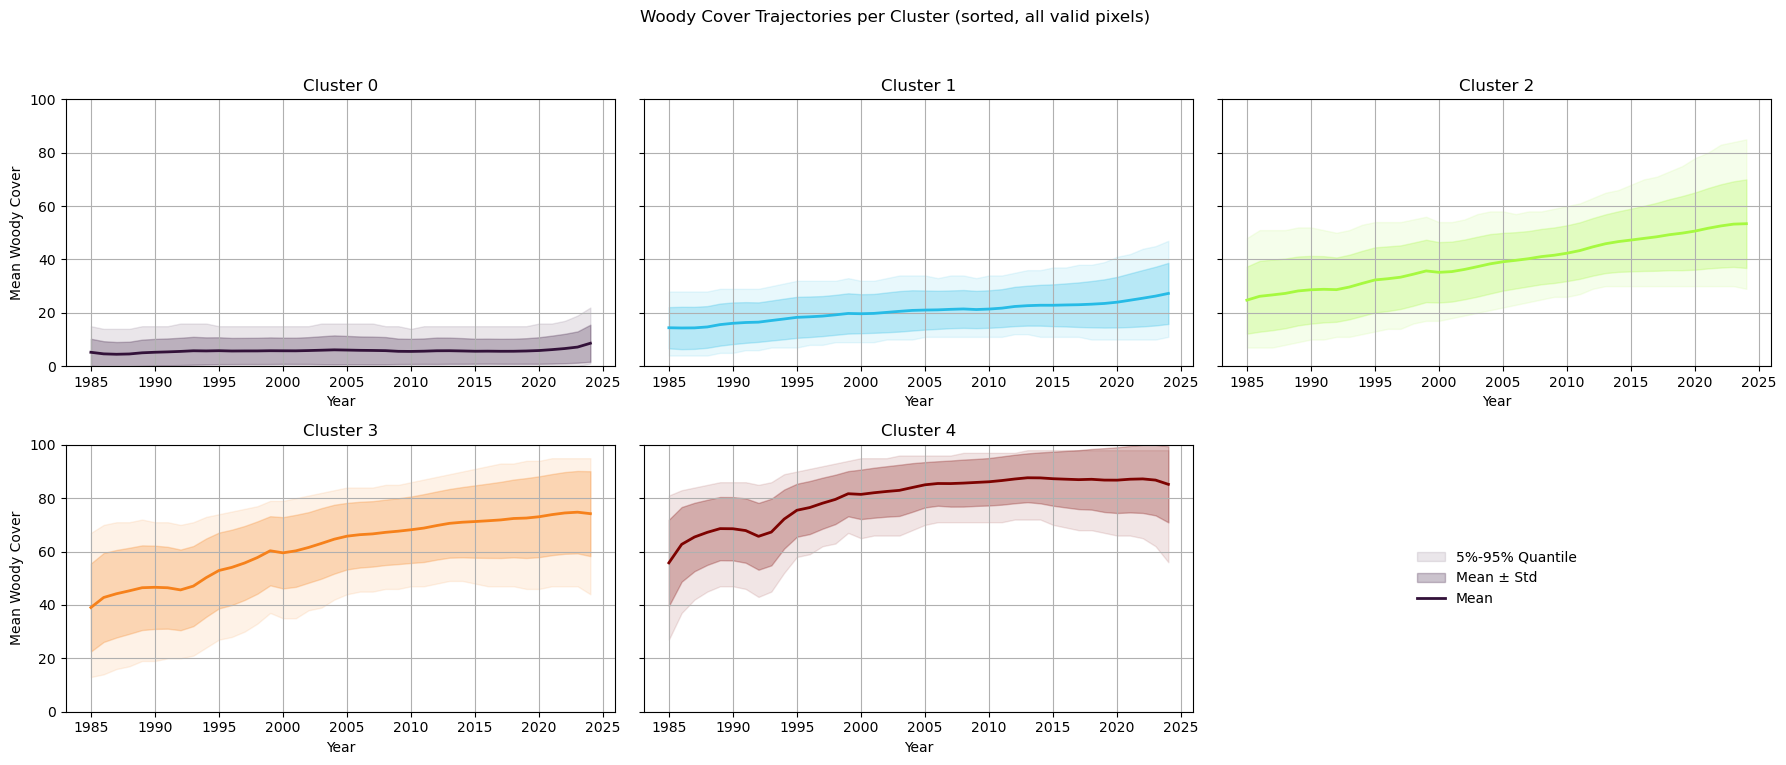

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Use existing woody, clusters, years, cluster_order, colors variables

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)  # 2 rows, 3 columns
axes = axes.flatten()
for idx, c in enumerate(cluster_order):
    ax = axes[idx]
    mask = clusters == c
    if np.sum(mask) == 0:
        ax.set_visible(False)
        continue
    cluster_ts = woody[:, mask]
    mean_ts = np.nanmean(cluster_ts, axis=1)
    std_ts = np.nanstd(cluster_ts, axis=1)
    q05_ts = np.nanquantile(cluster_ts, 0.05, axis=1)
    q95_ts = np.nanquantile(cluster_ts, 0.95, axis=1)
    ax.fill_between(years, q05_ts, q95_ts, color=colors[idx], alpha=0.10, label="5%-95% Quantile")
    ax.fill_between(years, mean_ts - std_ts, mean_ts + std_ts, color=colors[idx], alpha=0.25, label="Mean ± Std")
    ax.plot(years, mean_ts, color=colors[idx], label="Mean", linewidth=2)
    ax.set_title(f"Cluster {c}")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Year")
    if idx % 3 == 0:
        ax.set_ylabel("Mean Woody Cover")
    ax.grid()
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].axis('off')
axes[-1].legend(handles, labels, loc='center', fontsize=10, frameon=False)
plt.suptitle("Woody Cover Trajectories per Cluster (sorted, all valid pixels)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


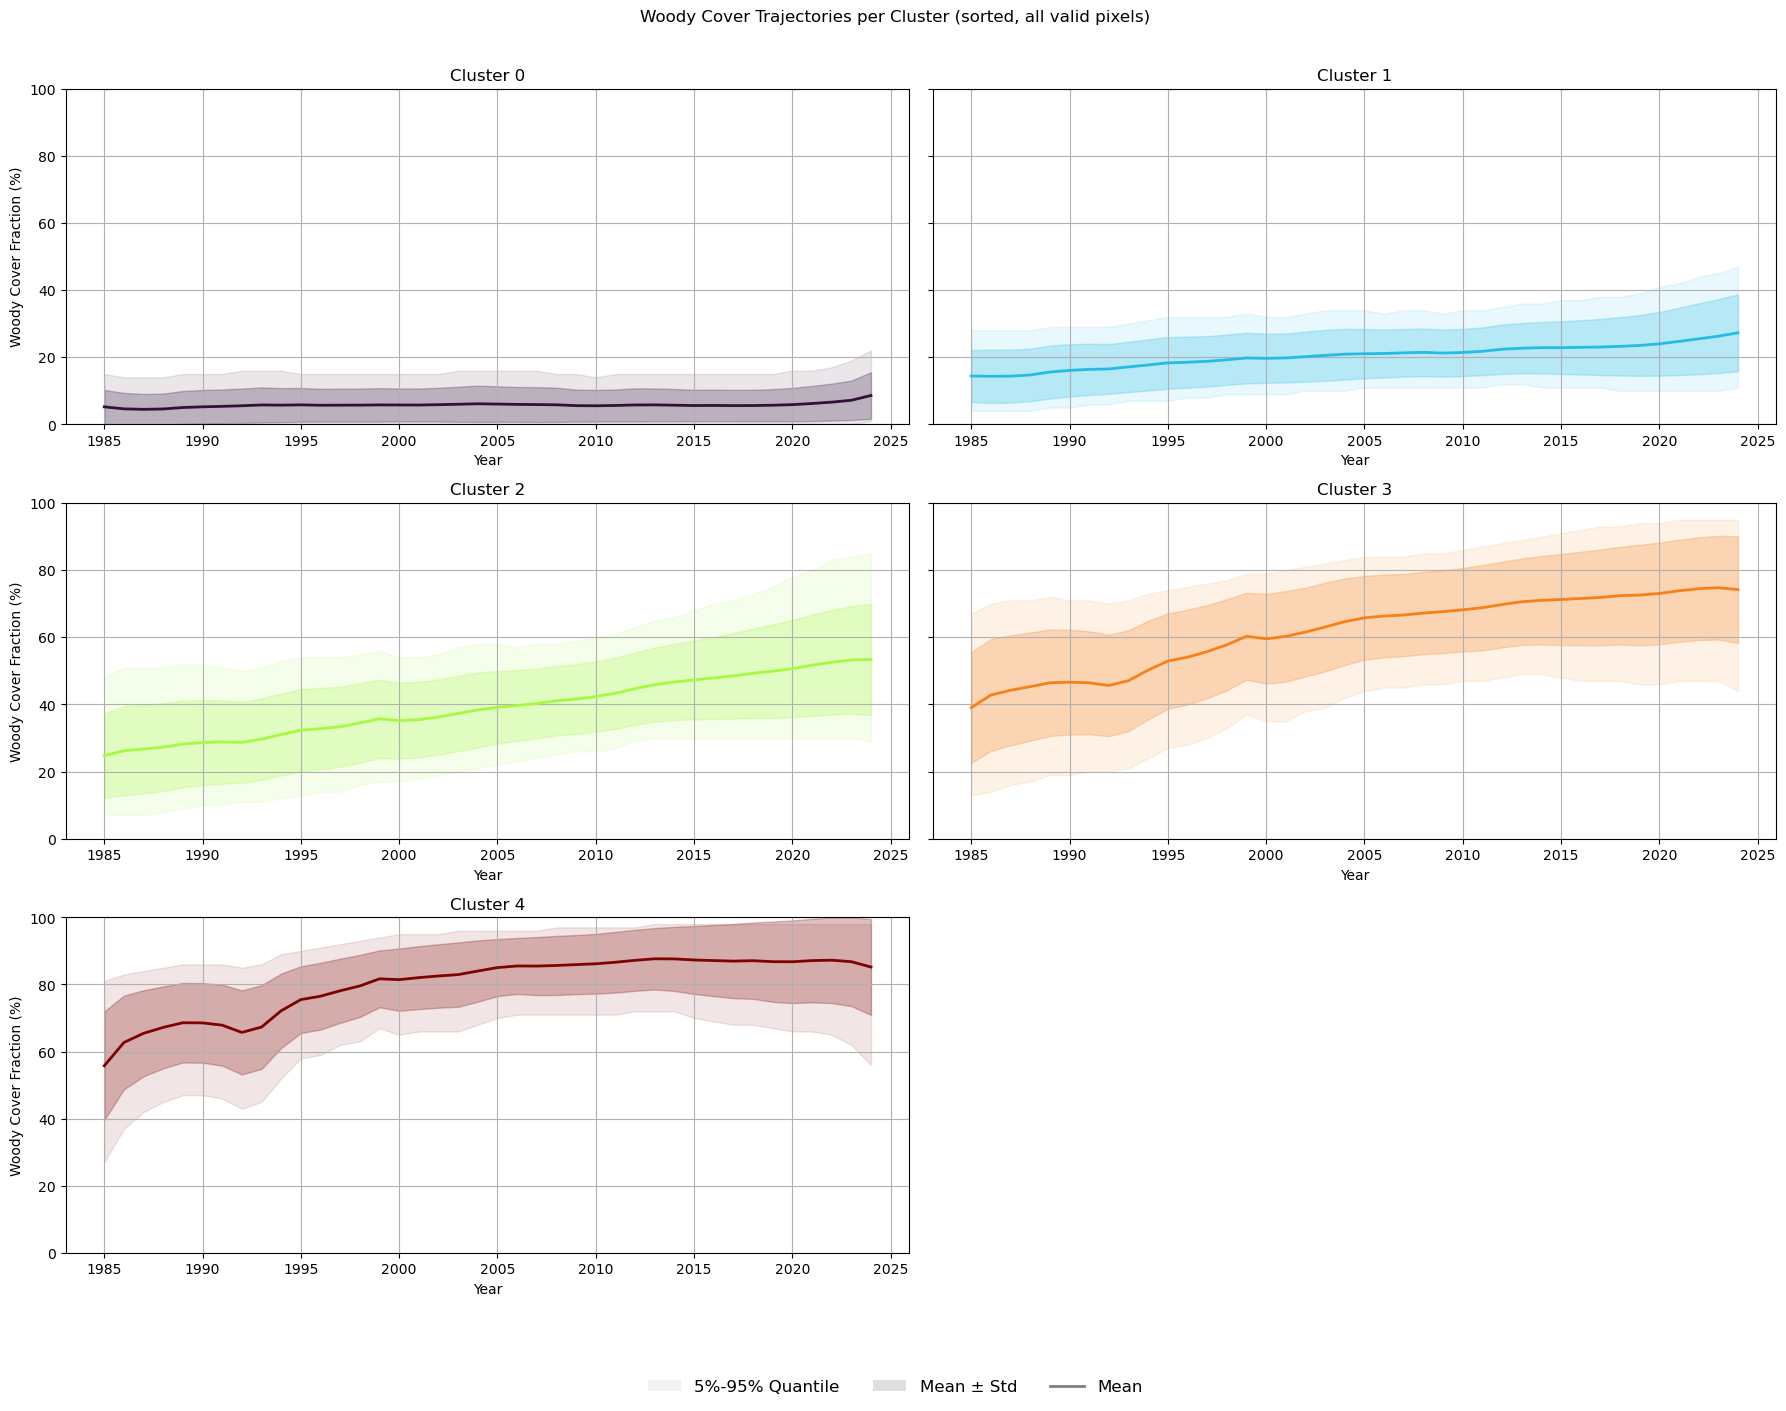

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

woody_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_3035_europe_masked.tif"
cluster_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif"

cluster_order = [0, 1, 2, 3, 4]
colors = ['#321139', '#26BBE6', '#A6F940', '#F6811B', '#7D0200']

with rasterio.open(woody_path) as src:
    woody = src.read()  # (bands, rows, cols)
years = np.arange(1985, 1985 + woody.shape[0])

with rasterio.open(cluster_path) as src:
    clusters = src.read(1)

fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()
for idx, c in enumerate(cluster_order):
    ax = axes[idx]
    mask = clusters == c
    if np.sum(mask) == 0:
        ax.set_visible(False)
        continue
    cluster_ts = woody[:, mask]
    mean_ts = np.nanmean(cluster_ts, axis=1)
    std_ts = np.nanstd(cluster_ts, axis=1)
    q05_ts = np.nanquantile(cluster_ts, 0.05, axis=1)
    q95_ts = np.nanquantile(cluster_ts, 0.95, axis=1)
    # Area between 5% and 95% quantile (very light)
    ax.fill_between(years, q05_ts, q95_ts, color=colors[idx], alpha=0.10)
    # Area between mean ± std (darker)
    ax.fill_between(years, mean_ts - std_ts, mean_ts + std_ts, color=colors[idx], alpha=0.25)
    # Mean
    ax.plot(years, mean_ts, color=colors[idx], linewidth=2)
    ax.set_title(f"Cluster {c}")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Year")
    if idx % 2 == 0:
        ax.set_ylabel("Woody Cover Fraction (%)")
    ax.grid()
# Leere Achsen ausblenden
for i in range(len(cluster_order), len(axes)):
    axes[i].set_visible(False)

# Dummy-Handles für die Legende
legend_elements = [
    Patch(facecolor='grey', alpha=0.10, label='5%-95% Quantile'),
    Patch(facecolor='grey', alpha=0.25, label='Mean ± Std'),
    Line2D([0], [0], color='grey', linewidth=2, label='Mean')
]

# Legende außerhalb des Plots platzieren
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Woody Cover Trajectories per Cluster (sorted, all valid pixels)")
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

### Piechart Cluster Class Frequency general and within Burn Scar

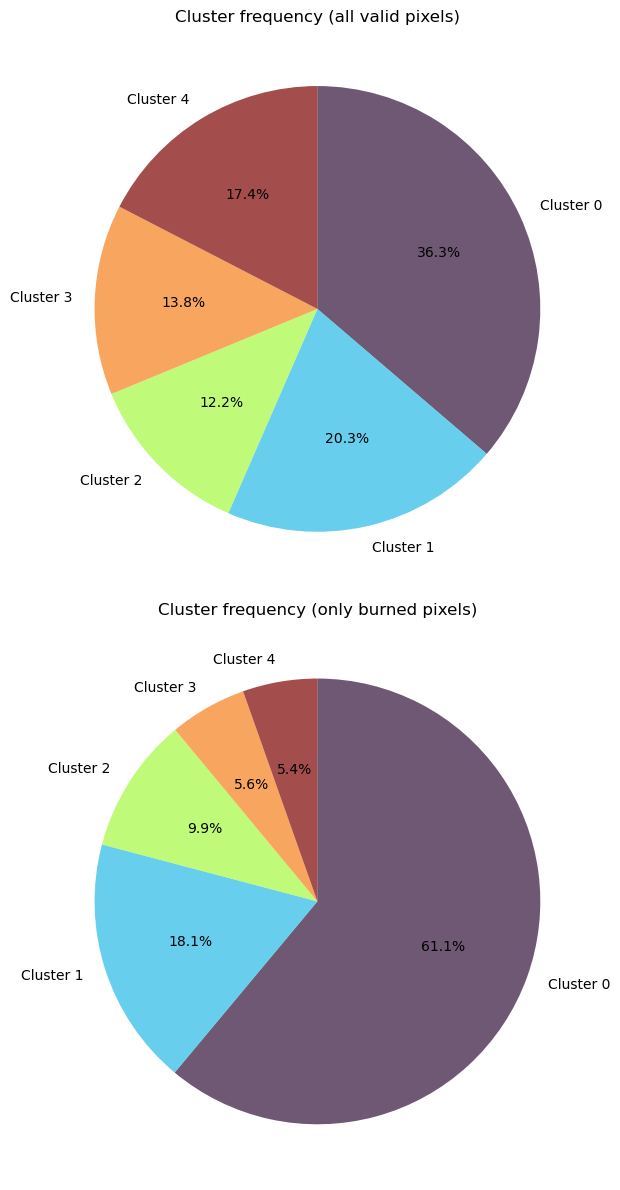

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Clusterfarben wie im Trajektorienplot, aber mit Transparenz (alpha=0.5)
base_colors = ['#321139', '#26BBE6', '#A6F940', '#F6811B', '#7D0200']
pie_colors = [to_rgba(c, alpha=0.7) for c in base_colors]
labels = [f"Cluster {c}" for c in range(5)]

# Pfade zu den sortierten Cluster-Rastern
cluster_all_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif"
cluster_burned_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned_sorted.tif"

# Piechart für alle gültigen Pixel
with rasterio.open(cluster_all_path) as src:
    clusters_all = src.read(1)
clusters_all_flat = clusters_all[clusters_all >= 0]
unique_all, counts_all = np.unique(clusters_all_flat.astype(int), return_counts=True)

# Piechart für nur burned area
with rasterio.open(cluster_burned_path) as src:
    clusters_burned = src.read(1)
clusters_burned_flat = clusters_burned[clusters_burned >= 0]
unique_burned, counts_burned = np.unique(clusters_burned_flat.astype(int), return_counts=True)

fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# Alle Pixel
axs[0].pie(counts_all, labels=[labels[c] for c in unique_all], colors=[pie_colors[c] for c in unique_all],
           autopct='%1.1f%%', startangle=90, counterclock=False)
axs[0].set_title("Cluster frequency (all valid pixels)")

# Nur burned area
axs[1].pie(counts_burned, labels=[labels[c] for c in unique_burned], colors=[pie_colors[c] for c in unique_burned],
           autopct='%1.1f%%', startangle=90, counterclock=False)
axs[1].set_title("Cluster frequency (only burned pixels)")

plt.tight_layout()
plt.show()

dominante Landcover-Klasse je Cluster innerhalb der Burn Scars (z.B. min. 1 Brandevent)

In [ ]:
import rasterio
import numpy as np
from collections import Counter

# Landcover-Legende
lc_legend = {
    1: "Crop",
    2: "Grassland",
    3: "Shrub",
    4: "Wetland",
    5: "Water",
    6: "Forest",
    7: "Urban",
    8: "Bare"
}
lc_codes = list(lc_legend.keys())
lc_names = [lc_legend[k] for k in lc_codes]

# Pfade
landcover_path = r"A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\basecover_3035_1990.tif"
cluster_all_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif"
cluster_burned_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned_sorted.tif"

# Landcover laden
with rasterio.open(landcover_path) as src:
    landcover = src.read(1)

# Cluster (alle Pixel)
with rasterio.open(cluster_all_path) as src:
    clusters_all = src.read(1)

# Cluster (nur burned area)
with rasterio.open(cluster_burned_path) as src:
    clusters_burned = src.read(1)

n_clusters = 5
print("Landcover distribution per cluster (all valid pixels):")
for c in range(n_clusters):
    mask = clusters_all == c
    lc_vals = landcover[mask]
    lc_vals = lc_vals[~np.isnan(lc_vals)]
    if len(lc_vals) == 0:
        print(f"  Cluster {c}: no valid landcover values")
        continue
    counts = Counter(lc_vals.astype(int))
    total = sum(counts.values())
    print(f"\n  Cluster {c}:")
    for lc_code in lc_codes:
        percent = 100 * counts.get(lc_code, 0) / total
        print(f"    {lc_legend[lc_code]:<10}: {percent:5.1f}% ({counts.get(lc_code, 0)})")

print("\nLandcover distribution per cluster (only burned pixels):")
for c in range(n_clusters):
    mask = clusters_burned == c
    lc_vals = landcover[mask]
    lc_vals = lc_vals[~np.isnan(lc_vals)]
    if len(lc_vals) == 0:
        print(f"  Cluster {c}: no valid landcover values")
        continue
    counts = Counter(lc_vals.astype(int))
    total = sum(counts.values())
    print(f"\n  Cluster {c}:")
    for lc_code in lc_codes:
        percent = 100 * counts.get(lc_code, 0) / total
        print(f"    {lc_legend[lc_code]:<10}: {percent:5.1f}% ({counts.get(lc_code, 0)})")

Landcover distribution per cluster (all valid pixels):

  Cluster 0:
    Crop      :  53.3% (235172)
    Grassland :  32.9% (145404)
    Shrub     :   0.0% (186)
    Wetland   :   0.3% (1111)
    Water     :   4.4% (19252)
    Forest    :   4.0% (17501)
    Urban     :   0.6% (2836)
    Bare      :   1.0% (4283)

  Cluster 1:
    Crop      :  30.6% (75461)
    Grassland :  40.8% (100657)
    Shrub     :   0.2% (600)
    Wetland   :   2.1% (5079)
    Water     :   0.9% (2100)
    Forest    :  15.9% (39302)
    Urban     :   1.3% (3109)
    Bare      :   0.1% (152)

  Cluster 2:
    Crop      :  16.7% (24796)
    Grassland :  28.4% (42190)
    Shrub     :   0.2% (367)
    Wetland   :   3.3% (4845)
    Water     :   0.7% (1033)
    Forest    :  45.5% (67673)
    Urban     :   1.0% (1539)
    Bare      :   0.0% (11)

  Cluster 3:
    Crop      :   7.6% (12727)
    Grassland :  12.6% (21168)
    Shrub     :   0.1% (130)
    Wetland   :   0.8% (1412)
    Water     :   0.5% (871)
    Forest  

C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

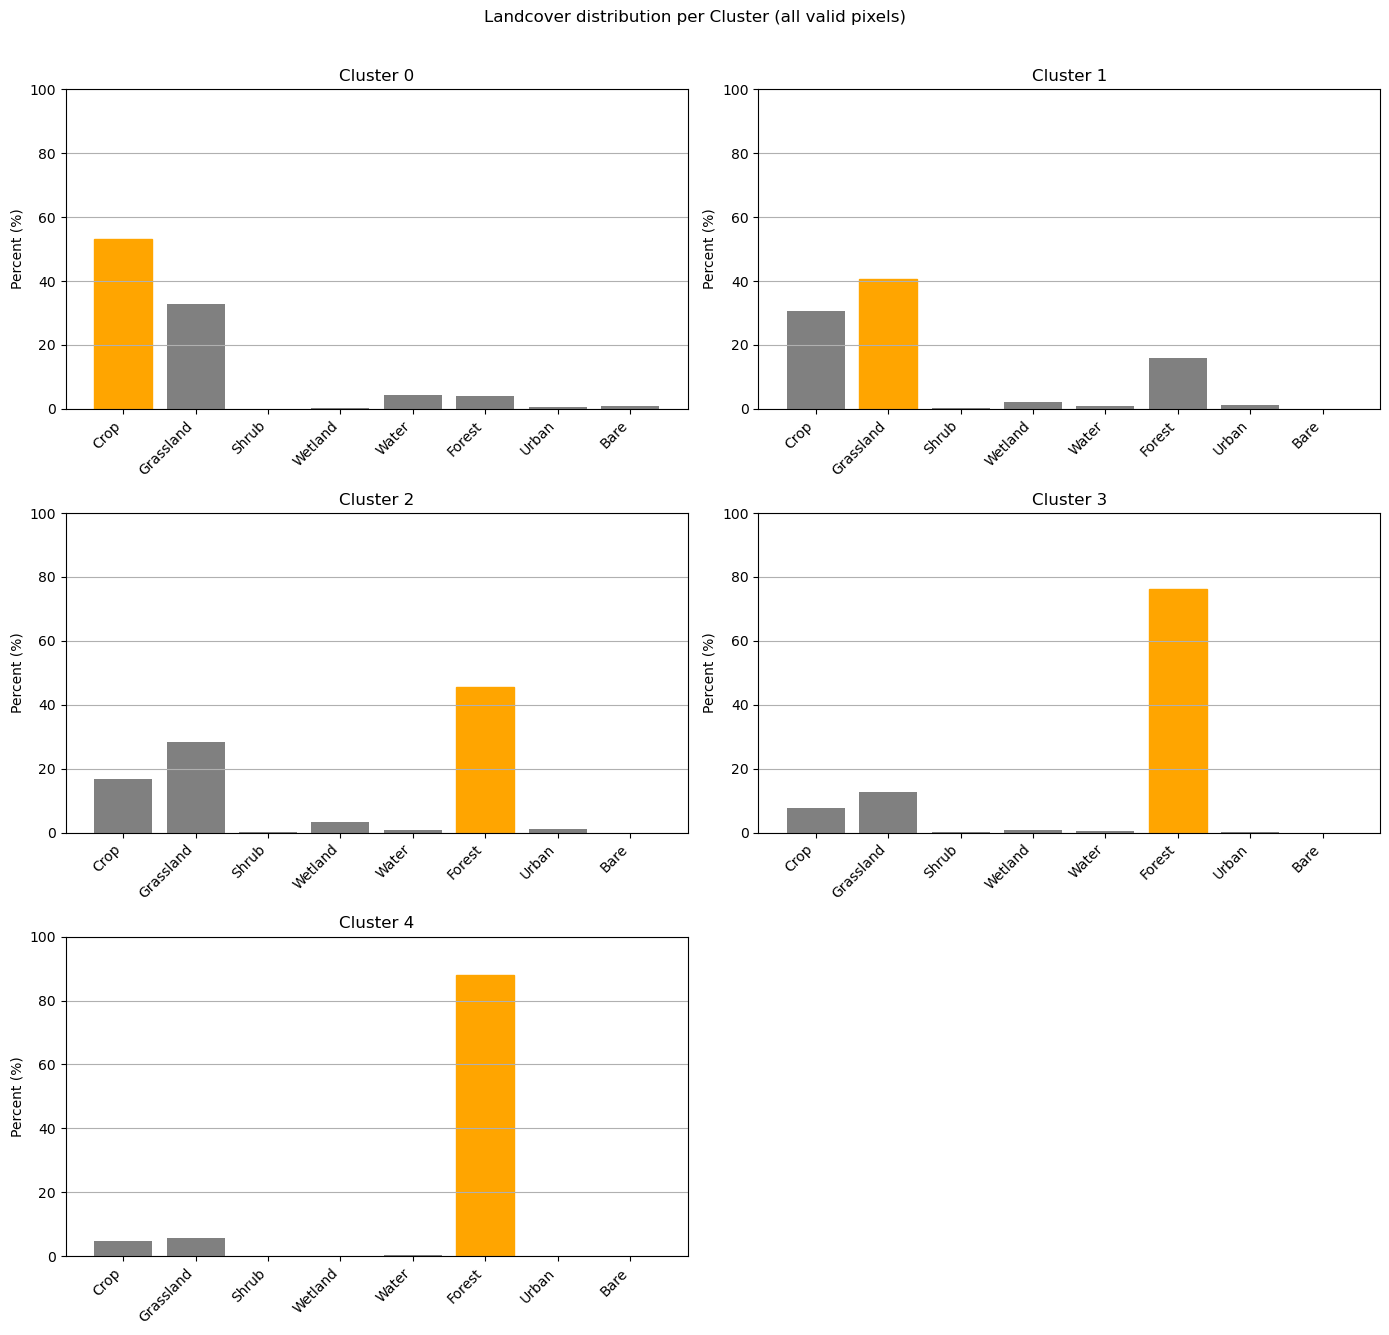

C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lc_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\2854475977.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

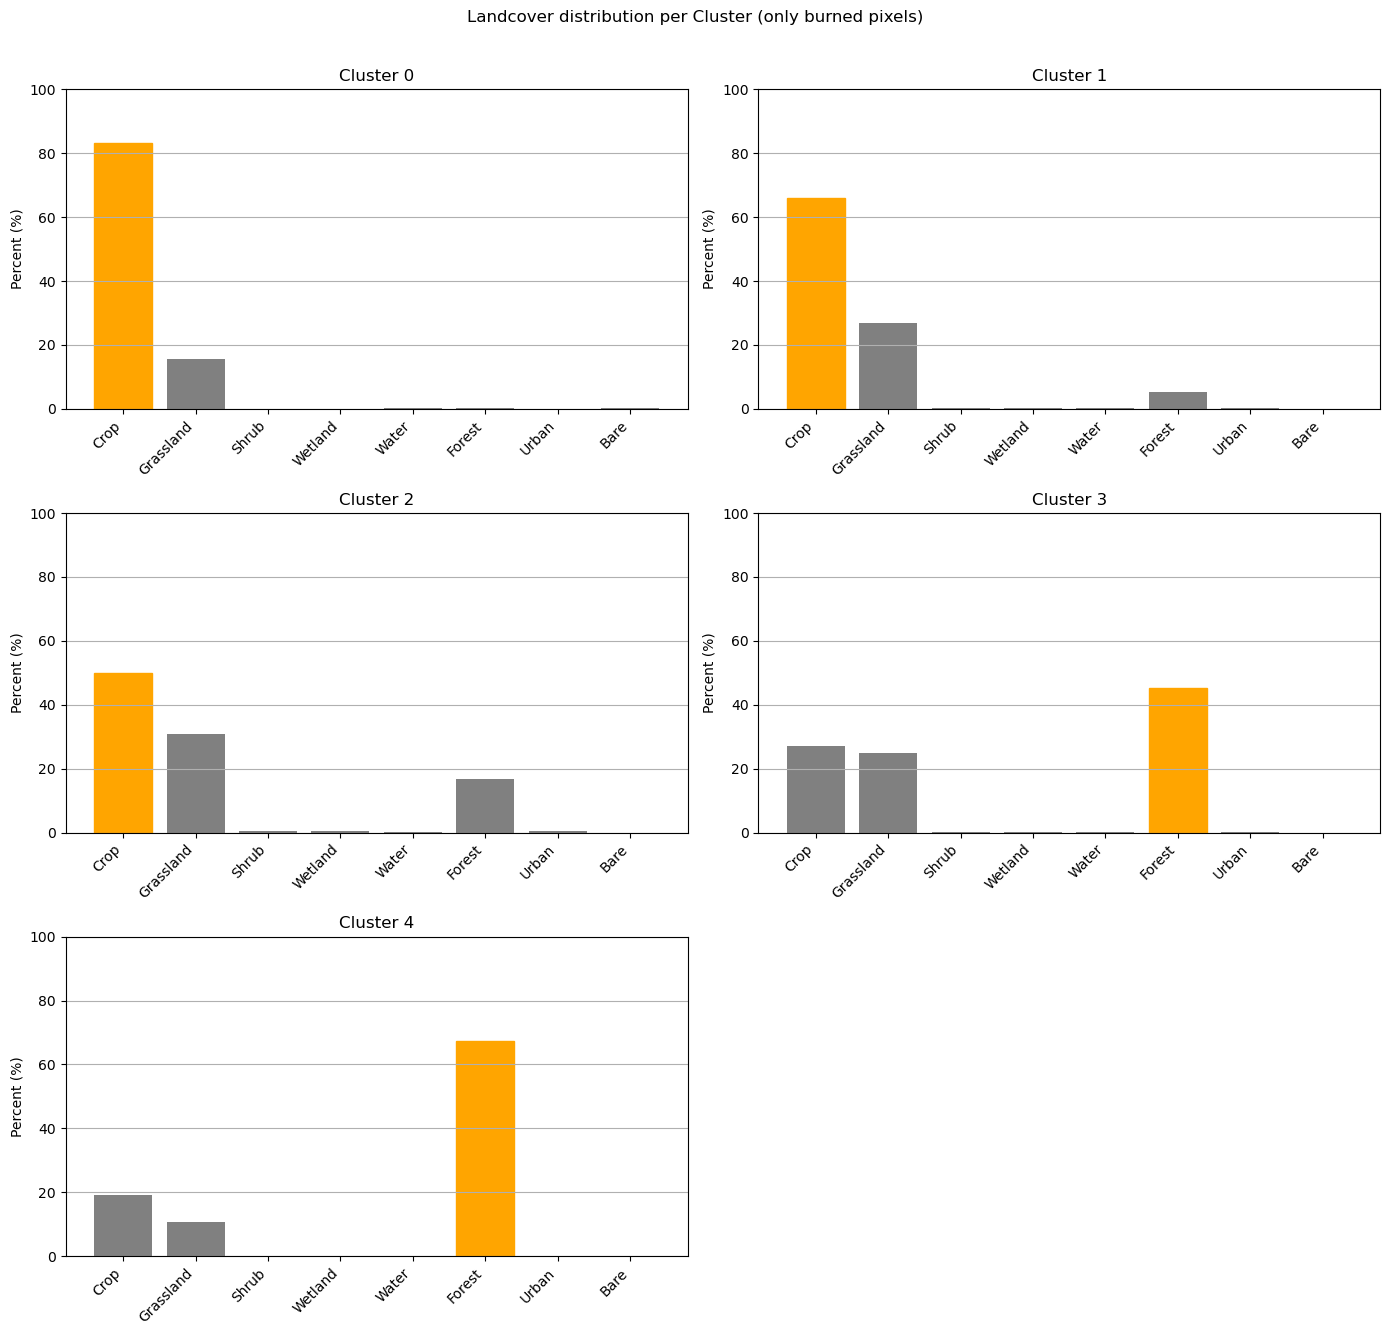

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Landcover-Legende
lc_legend = {
    1: "Crop",
    2: "Grassland",
    3: "Shrub",
    4: "Wetland",
    5: "Water",
    6: "Forest",
    7: "Urban",
    8: "Bare"
}
lc_codes = list(lc_legend.keys())
lc_names = [lc_legend[k] for k in lc_codes]

# Pfade
landcover_path = r"A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\basecover_3035_1990.tif"
cluster_all_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif"
cluster_burned_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned_sorted.tif"

# Landcover laden
with rasterio.open(landcover_path) as src:
    landcover = src.read(1)

# Cluster (alle Pixel)
with rasterio.open(cluster_all_path) as src:
    clusters_all = src.read(1)

# Cluster (nur burned area)
with rasterio.open(cluster_burned_path) as src:
    clusters_burned = src.read(1)

n_clusters = 5
cluster_labels = [f"Cluster {c}" for c in range(n_clusters)]

def plot_lc_distribution(clusters, title):
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()
    for c in range(n_clusters):
        ax = axes[c]
        mask = clusters == c
        lc_vals = landcover[mask]
        lc_vals = lc_vals[~np.isnan(lc_vals)]
        if len(lc_vals) == 0:
            ax.set_visible(False)
            continue
        counts = Counter(lc_vals.astype(int))
        total = sum(counts.values())
        percents = [100 * counts.get(code, 0) / total for code in lc_codes]
        bars = ax.bar(lc_names, percents, color='gray')
        # Highlight dominant class
        if percents:
            max_idx = int(np.argmax(percents))
            bars[max_idx].set_color('orange')
        ax.set_title(f"Cluster {c}")
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percent (%)")
        ax.set_xticklabels(lc_names, rotation=45, ha='right')
        ax.grid(axis='y')
    for i in range(n_clusters, len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

plot_lc_distribution(clusters_all, "Landcover distribution per Cluster (all valid pixels)")
plot_lc_distribution(clusters_burned, "Landcover distribution per Cluster (only burned pixels)")

C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklab

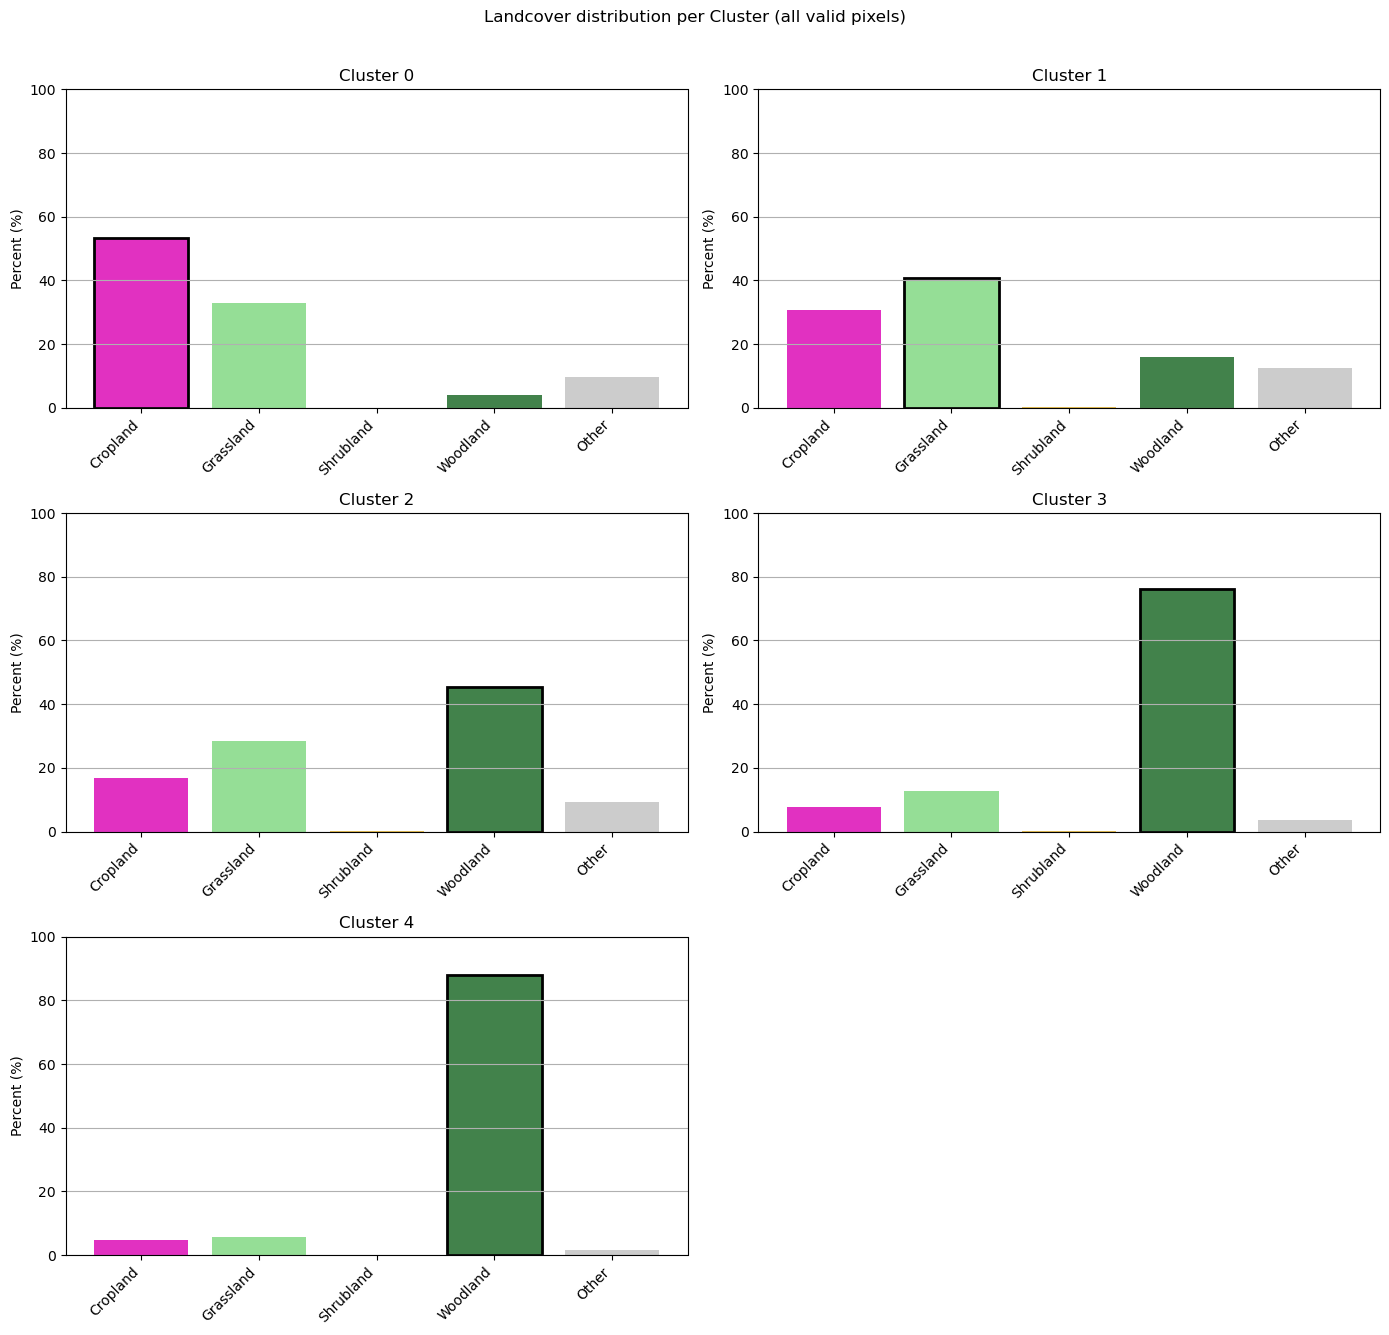

C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bar_names, rotation=45, ha='right')
C:\Users\butzerfe\AppData\Local\Temp\26\ipykernel_123316\1775455172.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklab

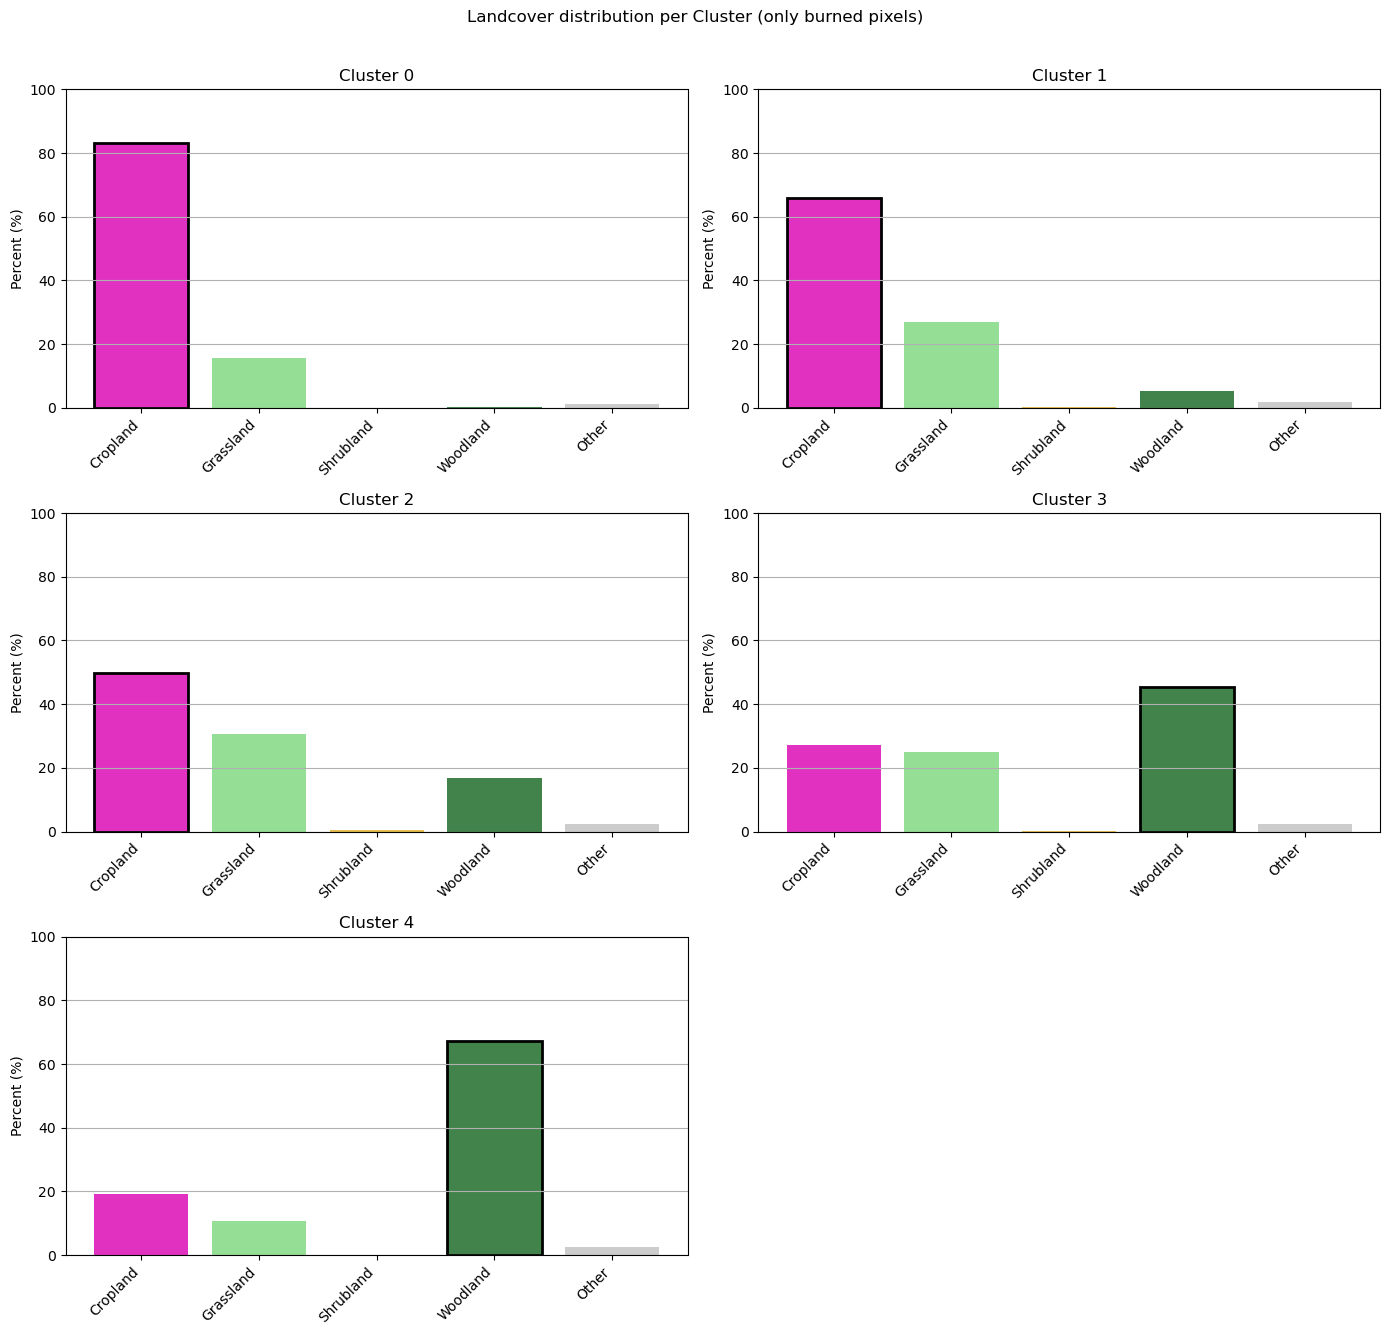

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Landcover-Legende und Farben
lc_legend = {
    1: ("Cropland", "#e131c1"),
    2: ("Grassland", "#95de96"),
    3: ("Shrubland", "#e6be4f"),
    6: ("Woodland", "#42824b")
}
main_codes = [1, 2, 3, 6]
main_names = [lc_legend[k][0] for k in main_codes]
main_colors = [lc_legend[k][1] for k in main_codes]
other_name = "Other"
other_color = "#cccccc"

# Pfade
landcover_path = r"A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\basecover_3035_1990.tif"
cluster_all_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_sorted.tif"
cluster_burned_path = r"A:\_BioGeo\butzerfe\thesis\_Runs\02_Woody_Metrics\Cluster\woody_cover_3035_cluster_masked_burned_sorted.tif"

# Landcover laden
with rasterio.open(landcover_path) as src:
    landcover = src.read(1)

# Cluster (alle Pixel)
with rasterio.open(cluster_all_path) as src:
    clusters_all = src.read(1)

# Cluster (nur burned area)
with rasterio.open(cluster_burned_path) as src:
    clusters_burned = src.read(1)

n_clusters = 5

def plot_lc_distribution(clusters, title):
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()
    for c in range(n_clusters):
        ax = axes[c]
        mask = clusters == c
        lc_vals = landcover[mask]
        lc_vals = lc_vals[~np.isnan(lc_vals)]
        if len(lc_vals) == 0:
            ax.set_visible(False)
            continue
        counts = Counter(lc_vals.astype(int))
        total = sum(counts.values())
        percents = []
        for code in main_codes:
            percents.append(100 * counts.get(code, 0) / total)
        # "Other" berechnen
        other_count = total - sum([counts.get(code, 0) for code in main_codes])
        percents.append(100 * other_count / total)
        bar_names = main_names + [other_name]
        bar_colors = main_colors + [other_color]
        bars = ax.bar(bar_names, percents, color=bar_colors)
        # Highlight dominant class in its legend color
        if percents:
            max_idx = int(np.argmax(percents))
            for i, bar in enumerate(bars):
                if i == max_idx:
                    bar.set_edgecolor('black')
                    bar.set_linewidth(2)
        ax.set_title(f"Cluster {c}")
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percent (%)")
        ax.set_xticklabels(bar_names, rotation=45, ha='right')
        ax.grid(axis='y')
    for i in range(n_clusters, len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

plot_lc_distribution(clusters_all, "Landcover distribution per Cluster (all valid pixels)")
plot_lc_distribution(clusters_burned, "Landcover distribution per Cluster (only burned pixels)")

Die Barplots zeigen für jeden Cluster die prozentuale Verteilung der Landcover-Klassen an.

Für jeden Cluster siehst du:

Crop: Anteil der Pixel im Cluster, die als Ackerland klassifiziert sind
Grassland: Anteil der Pixel mit Grasland
Shrub: Anteil der Pixel mit Strauchland
Forest: Anteil der Pixel mit Wald
Other: Anteil der Pixel, die zu allen anderen Landcover-Klassen gehören (z.B. Wasser, Siedlung, Brachland usw.)
Die Höhe jedes Balkens entspricht dem Prozentsatz dieser Landcover-Klasse innerhalb des jeweiligen Clusters (alle Pixel des Clusters = 100 %).

Zwei Panelplots:

Einmal für alle Pixel (gesamtes Cluster)
Einmal nur für Pixel innerhalb der Burned Area (gebrannte Pixel)
So kannst du ablesen, welche Landcover-Typen in welchem Cluster dominieren und wie sich die Zusammensetzung zwischen allen Pixeln und nur den gebrannten Pixeln unterscheidet.

## Rproject BaseCover to EPSG 3035 and aggregate to fire grid size (0.5km)


In [ ]:
# --- Pfade zu Input- und Output-Dateien definieren ---
basecover_vrt = r"A:\_BioGeo\wildE\_PREDICTIONS\Run02_Okt2024\01_BaseCover_1989.vrt"
template_raster = r"A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\woody_cover_500m_3035.tif"
out_basecover = r"A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\basecover_500m_3035_1990.tif"


# --- Zielraster-Parameter (Grid, Projektion, Auflösung) von der Burned Mask lesen ---
print("Lese Zielraster-Parameter von der Burned Mask ...")
# Zielraster-Parameter vom Template lesen
tmpl = gdal.Open(template_raster)
gt = tmpl.GetGeoTransform()
proj = tmpl.GetProjection()
x_size = tmpl.RasterXSize
y_size = tmpl.RasterYSize


# --- Reprojektion und Resampling des Basecover Rasters auf das Grid der Burned Mask und woody Cover ---
print("Starte Reprojektion mit GDAL ...")
start = time.time()
gdal.Warp(
    out_basecover,              # Zielpfad für das reprojizierte Raster
    basecover_vrt,              # Input-Raster
    format='GTiff',             # Ausgabeformat GeoTIFF
    outputBounds=(gt[0], gt[3] + y_size * gt[5], gt[0] + x_size * gt[1], gt[3]), # Bounding Box wie Burned Mask
    xRes=gt[1],                 # Pixelgröße X wie Burned Mask
    yRes=abs(gt[5]),            # Pixelgröße Y wie Burned Mask (positiv)
    dstSRS=proj,                # Ziel-Koordinatensystem wie Burned Mask
    resampleAlg='mode',         # Für Kategorische Daten!
    multithread=True,           # Mehrere CPU-Kerne nutzen
    options=['COMPRESS=LZW']        # LZW-Komprimierung für kleinere Datei
)
end = time.time()

# --- Abschlussmeldung mit Zeitangabe und Speicherort ---
print(f"Reprojektion abgeschlossen. Dauer: {end-start:.1f} Sekunden")
print(f"Reprojiziertes Basecover gespeichert unter: {out_basecover}")

Lese Zielraster-Parameter von der Burned Mask ...
Starte Reprojektion mit GDAL ...
Reprojektion abgeschlossen. Dauer: 519.7 Sekunden
Reprojiziertes Basecover gespeichert unter: A:\_BioGeo\butzerfe\thesis\_00_SHAPEFILES\basecover_500m_3035_1990.tif
